# H7 — Boundary Position × Condition  |  DV: **REC** (Recognition Discrimination Index)

**Test:** Mixed-Model ANOVA (within: boundary\_position; between: condition)  
**DV:** REC — Recognition Discrimination Index  
**Question:** Does where an item appeared (Pre / Mid / Post) affect REC? Does it interact with condition?  
**Hypothesis:** Boundary position significantly affects REC, with a potential condition interaction.

**Analysis pipeline:**
1. Data loading & preprocessing  
2. Assumption checks — normality (Shapiro–Wilk) & homogeneity of variance (Levene / Mauchly)  
3. Mixed-Model ANOVA  
4. Post hoc tests (Bonferroni-corrected pairwise comparisons)  
5. Visualisations

In [24]:
import warnings
import numpy as np
import pandas as pd
import pingouin as pg
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

In [25]:
def _header(title, width=75):
    print("\n" + "═" * width)
    print(f"  {title}")
    print("═" * width)

def _get_p(row):
    for c in row.index:
        if c in ("p-unc", "p-val", "p_val", "p_unc", "p"):
            return float(row[c])
    raise KeyError(f"No p-value column. Available: {list(row.index)}")

def _sig(p):
    return "✅ Significant" if p < 0.05 else "❌ Not Significant"

def _stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

ALPHA = 0.05
DV    = "REC"   # dependent variable for this notebook

In [26]:
CSV_PATH = "compiled_preprocessed.csv"   # <-- update path if needed

df = pd.read_csv(CSV_PATH)

col_candidates = {
    "participant": ["participant_uid", "participant_id", "Participant_ID"],
    "condition":   ["condition", "Condition"],
    "trial_type":  ["trial_type", "Trial_Type"],
    "response":    ["user_response", "response", "User_Response"],
    "position":    ["boundary_position", "Boundary_Position"],
    "rt":          ["encoding_RT", "Encoding_RT", "encoding_rt", "RT_encoding", "RT"],
}
resolved = {}
for key, candidates in col_candidates.items():
    resolved[key] = next((c for c in candidates if c in df.columns), None)

required_keys = ["participant", "condition", "trial_type", "response", "position"]
missing = [k for k in required_keys if resolved[k] is None]
if missing:
    raise ValueError(f"Missing required columns for {missing}. Found: {list(df.columns)}")

if resolved["rt"] is not None:
    df["Encoding_RT"] = pd.to_numeric(df[resolved["rt"]], errors="coerce")
else:
    df["Encoding_RT"] = np.nan
    print("Warning: No encoding RT column found.")

pid_col   = resolved["participant"]
cond_col  = resolved["condition"]
trial_col = resolved["trial_type"]
resp_col  = resolved["response"]
pos_col   = resolved["position"]

df[cond_col] = df[cond_col].astype(str).str.strip()

# ── Global rates (1 row per participant) ──────────────────────────────────────
g_records = []
for uid, g in df.groupby(pid_col):
    cond    = g[cond_col].iloc[0]
    foils   = g[g[trial_col] == "Foil"]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    fa_t = (foils[resp_col]   == "Target").mean() if len(foils)   > 0 else 0.0
    fa_l = (foils[resp_col]   == "Lure"  ).mean() if len(foils)   > 0 else 0.0
    hit  = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    sim  = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    g_records.append({
        "participant_uid": uid, "condition": cond,
        "FA_Target": fa_t, "FA_Lure": fa_l,
        "Hit_Rate": hit,   "Sim_Rate": sim,
        "REC": hit - fa_t, "LDI": sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
global_df = pd.DataFrame(g_records)
global_df.dropna(subset=["REC", "LDI"], inplace=True)

# ── Position-specific rates ───────────────────────────────────────────────────
p_records = []
pos_trials = df[df[pos_col].isin(["Pre", "Mid", "Post"])]
for (uid, pos), g in pos_trials.groupby([pid_col, pos_col]):
    cond    = g[cond_col].iloc[0]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    pos_hit = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    pos_sim = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    fa_row  = global_df[global_df["participant_uid"] == uid]
    fa_t    = float(fa_row["FA_Target"].values[0]) if len(fa_row) > 0 else 0.0
    fa_l    = float(fa_row["FA_Lure"  ].values[0]) if len(fa_row) > 0 else 0.0
    p_records.append({
        "participant_uid": uid, "condition": cond,
        "boundary_position": pos,
        "REC": pos_hit - fa_t, "LDI": pos_sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
position_df = pd.DataFrame(p_records)
counts = position_df.groupby("participant_uid")["boundary_position"].nunique()
valid  = counts[counts == 3].index
position_df = position_df[position_df["participant_uid"].isin(valid)].copy()
position_df.dropna(subset=["REC", "LDI"], inplace=True)

model_df = position_df[["participant_uid","condition","boundary_position", DV]].dropna()

order      = ["Pre", "Mid", "Post"]
cond_order = sorted(model_df["condition"].unique())
palette    = sns.color_palette("Set2", len(cond_order))
cond_colors = dict(zip(cond_order, palette))

print(f"Global subjects                              : {len(global_df)}")
print(f"Position subjects (balanced, 3 positions)    : {model_df['participant_uid'].nunique()}")
print(f"Analysis DV                                  : {DV}")

Global subjects                              : 160
Position subjects (balanced, 3 positions)    : 160
Analysis DV                                  : REC


---
## Assumption Checks

Before running the Mixed-Model ANOVA, three assumptions are tested:

| # | Assumption | Test | Scope |
|---|---|---|---|
| 1 | **Normality** of residuals within each cell | Shapiro–Wilk (W, p) | Each condition × position cell |
| 2 | **Homogeneity of variance** (between-subjects) | Levene's test | REC variance across conditions at each position |
| 3 | **Sphericity** (within-subjects) | Mauchly's W | boundary\_position levels |

> **Interpretation guide:** Shapiro–Wilk p > .05 → normality tenable. Levene p > .05 → equal variances tenable. Mauchly p > .05 → sphericity tenable (no Greenhouse–Geisser correction needed).

In [27]:
_header(f"Assumption Checks — DV: {DV}")

# ── 1. Shapiro–Wilk normality per cell (condition × position) ─────────────────
print("\n  [1] Shapiro–Wilk Normality Test — per condition × position cell")
print(f"  {'─'*65}")
print(f"  {"Condition":<25} {"Position":<8} {"n":>4}  {"W":>7}  {"p":>8}  Result")
print(f"  {'─'*65}")

any_violation = False
for cond in cond_order:
    for pos in order:
        cell = model_df[(model_df["condition"] == cond) &
                        (model_df["boundary_position"] == pos)][DV].dropna()
        n = len(cell)
        if n < 3:
            print(f"  {cond:<25} {pos:<8} {n:>4}      N/A       N/A  ⚠️  Too few obs")
            continue
        W, p = stats.shapiro(cell)
        flag = "✅ Normal" if p > ALPHA else "❌ Violation"
        if p <= ALPHA:
            any_violation = True
        print(f"  {cond:<25} {pos:<8} {n:>4}  {W:>7.4f}  {p:>8.4f}  {flag}")

print()
if any_violation:
    print("  ⚠️  One or more cells show non-normality.")
    print("     Mixed ANOVA is robust to moderate violations with balanced designs.")
    print("     Consider non-parametric alternatives (e.g., aligned-rank transform) if severe.")
else:
    print("  ✅ All cells satisfy normality assumption.")

# ── 2. Levene's test — homogeneity of variance (between-subjects) ─────────────
print("\n  [2] Levene's Test — Homogeneity of Variance (condition) at each position")
print(f"  {'─'*55}")
print(f"  {"Position":<8} {"F":>8}  {"p":>8}  Result")
print(f"  {'─'*55}")

for pos in order:
    groups = [
        model_df[(model_df["boundary_position"] == pos) &
                 (model_df["condition"] == cond)][DV].dropna().values
        for cond in cond_order
    ]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        print(f"  {pos:<8}      N/A       N/A  ⚠️  Insufficient groups")
        continue
    F, p = stats.levene(*groups, center="median")
    flag = "✅ Equal variances" if p > ALPHA else "❌ Violation"
    print(f"  {pos:<8} {F:>8.4f}  {p:>8.4f}  {flag}")

# Also overall (collapsed across positions)
overall_groups = [
    model_df[model_df["condition"] == cond][DV].dropna().values
    for cond in cond_order
]
F_ov, p_ov = stats.levene(*overall_groups, center="median")
flag_ov = "✅ Equal variances" if p_ov > ALPHA else "❌ Violation"
print(f"  {"Overall":<8} {F_ov:>8.4f}  {p_ov:>8.4f}  {flag_ov}")

# ── 3. Mauchly's Sphericity test (within-subjects: boundary_position) ─────────
print("\n  [3] Mauchly's Test of Sphericity — boundary_position")
print(f"  {'─'*55}")
try:
    sph = pg.sphericity(
        data=model_df, dv=DV,
        within="boundary_position",
        subject="participant_uid"
    )
    # pingouin returns (spher, W, chi2, dof, pval)
    if isinstance(sph, tuple):
        spher, W_s, chi2, dof_s, p_s = sph
    else:
        W_s  = float(sph["W"].values[0])
        chi2 = float(sph["chi2"].values[0])
        dof_s = float(sph["dof"].values[0])
        p_s  = float(sph["pval"].values[0])
        spher = p_s > ALPHA
    flag_s = "✅ Sphericity tenable" if p_s > ALPHA else "❌ Sphericity violated — GG correction will be applied"
    print(f"  Mauchly W = {W_s:.4f},  χ²({dof_s:.0f}) = {chi2:.3f},  p = {p_s:.4f}")
    print(f"  {flag_s}")
    if p_s <= ALPHA:
        print("  → Greenhouse–Geisser corrected F and p will be reported by pingouin automatically.")
except Exception as e:
    print(f"  Could not compute sphericity: {e}")


═══════════════════════════════════════════════════════════════════════════
  Assumption Checks — DV: REC
═══════════════════════════════════════════════════════════════════════════

  [1] Shapiro–Wilk Normality Test — per condition × position cell
  ─────────────────────────────────────────────────────────────────
  Condition                 Position    n        W         p  Result
  ─────────────────────────────────────────────────────────────────
  Both_item_task            Pre        51   0.9835    0.6927  ✅ Normal
  Both_item_task            Mid        51   0.9717    0.2598  ✅ Normal
  Both_item_task            Post       51   0.9892    0.9221  ✅ Normal
  item_only                 Pre        56   0.9725    0.2282  ✅ Normal
  item_only                 Mid        56   0.9683    0.1473  ✅ Normal
  item_only                 Post       56   0.9619    0.0740  ✅ Normal
  task_only                 Pre        53   0.9094    0.0007  ❌ Violation
  task_only                 Mid        53   0

---
## Mixed-Model ANOVA — DV: REC

- **Within-subjects factor:** boundary\_position (Pre / Mid / Post)  
- **Between-subjects factor:** condition  
- **Subject:** participant\_uid  

Greenhouse–Geisser correction is applied automatically by pingouin when sphericity is violated.

In [28]:
_header(f"Mixed-Model ANOVA — DV: {DV}")
print(f"  Subjects : {model_df['participant_uid'].nunique()}")
print(f"  Within   : boundary_position (Pre / Mid / Post)")
print(f"  Between  : condition ({', '.join(cond_order)})")
print()

mix = pg.mixed_anova(
    data=model_df, dv=DV,
    within="boundary_position", between="condition",
    subject="participant_uid",
    correction=True          # auto GG if sphericity violated
)

# Store for post hoc gating
_anova_results = {}
for _, row in mix.iterrows():
    src = str(row["Source"]).replace("*","×")
    p_val = _get_p(row)
    es_col = next((c for c in row.index if c in ("np2","eta-sq","eta2","eta2-p")), None)
    es_str = f"η²p = {row[es_col]:.3f}" if es_col else ""
    _anova_results[src] = p_val
    print(f"  {src:<35} | F = {row['F']:>7.3f}   p = {p_val:>8.4f}   {_sig(p_val)}   {es_str}")

p_pos   = _anova_results.get("boundary_position")
p_cond  = _anova_results.get("condition")
p_inter = _anova_results.get("boundary_position × condition",
          _anova_results.get("boundary_position*condition",
          _anova_results.get("Interaction")))

print()
print(mix[["Source","DF1","DF2","F","p_unc","np2"]].to_string(index=False))


═══════════════════════════════════════════════════════════════════════════
  Mixed-Model ANOVA — DV: REC
═══════════════════════════════════════════════════════════════════════════
  Subjects : 160
  Within   : boundary_position (Pre / Mid / Post)
  Between  : condition (Both_item_task, item_only, task_only)

  condition                           | F =   0.976   p =   0.3790   ❌ Not Significant   η²p = 0.012
  boundary_position                   | F =   4.635   p =   0.0104   ✅ Significant   η²p = 0.029
  Interaction                         | F =   2.989   p =   0.0191   ✅ Significant   η²p = 0.037

           Source  DF1  DF2        F    p_unc      np2
        condition    2  157 0.976291 0.378981 0.012284
boundary_position    2  314 4.635299 0.010377 0.028678
      Interaction    4  314 2.989164 0.019131 0.036682


---
## Post Hoc Tests — DV: REC

Comparisons are run **only when the parent ANOVA term is significant (p < .05)**. All p-values are Bonferroni-corrected.

| # | Effect | Test |
|---|---|---|
| 1 | Main effect — boundary\_position (within) | Paired t-tests: Pre vs Mid, Pre vs Post, Mid vs Post |
| 2 | Main effect — condition (between) | Independent t-tests across condition pairs |
| 3a | Interaction — within each condition | Paired position comparisons per condition |
| 3b | Interaction — within each position | Between-condition comparisons at Pre / Mid / Post |

In [29]:
_header(f"Post Hoc Tests — DV: {DV}")

# ── [1] Main effect: boundary_position ───────────────────────────────────────
print(f"\n  [1] boundary_position  (ANOVA p = {p_pos:.4f} → {_sig(p_pos)})")
if p_pos is not None and p_pos < ALPHA:
    ph1 = pg.pairwise_tests(
        data=model_df, dv=DV,
        within="boundary_position",
        subject="participant_uid",
        parametric=True, padjust="bonf"
    )
    print(f"  {'─'*70}")
    print(f"  {"A":<6} {"B":<6}  {"t":>8}  {"df":>5}  {"p_unc":>8}  {"p_bonf":>8}  Result")
    print(f"  {'─'*70}")
    for _, r in ph1.iterrows():
        print(f"  {r['A']:<6} {r['B']:<6}  {r['T']:>+8.3f}  {r['dof']:>5.0f}"
              f"  {r['p_unc']:>8.4f}  {r['p_corr']:>8.4f}  {_sig(r['p_corr'])}")
else:
    print("    ↳ Skipped — parent effect not significant")

# ── [2] Main effect: condition ────────────────────────────────────────────────
print(f"\n  [2] condition          (ANOVA p = {p_cond:.4f} → {_sig(p_cond)})")
if p_cond is not None and p_cond < ALPHA:
    wide = model_df.groupby(["participant_uid","condition"])[DV].mean().reset_index()
    ph2 = pg.pairwise_tests(
        data=wide, dv=DV,
        between="condition",
        parametric=True, padjust="bonf"
    )
    print(f"  {'─'*80}")
    print(f"  {"A":<22} {"B":<22}  {"t":>8}  {"df":>5}  {"p_unc":>8}  {"p_bonf":>8}  Result")
    print(f"  {'─'*80}")
    for _, r in ph2.iterrows():
        print(f"  {r['A']:<22} {r['B']:<22}  {r['T']:>+8.3f}  {r['dof']:>5.0f}"
              f"  {r['p_unc']:>8.4f}  {r['p_corr']:>8.4f}  {_sig(r['p_corr'])}")
else:
    print("    ↳ Skipped — parent effect not significant")

# ── [3] Interaction simple effects ───────────────────────────────────────────
print(f"\n  [3] Interaction        (ANOVA p = {p_inter:.4f} → {_sig(p_inter)})")
if p_inter is not None and p_inter < ALPHA:

    # 3a — within each condition, compare positions
    print("\n    3a. Position comparisons within each condition (paired t, Bonferroni):")
    for cond in cond_order:
        sub = model_df[model_df["condition"] == cond]
        ph3a = pg.pairwise_tests(
            data=sub, dv=DV,
            within="boundary_position",
            subject="participant_uid",
            parametric=True, padjust="bonf"
        )
        print(f"\n      Condition = {cond}:")
        print(f"      {'─'*65}")
        for _, r in ph3a.iterrows():
            print(f"      {r['A']:<6} vs {r['B']:<6}  t({r['dof']:.0f}) = {r['T']:>+7.3f}"
                  f"  p_unc={r['p_unc']:.4f}  p_bonf={r['p_corr']:.4f}  {_sig(r['p_corr'])}")

    # 3b — within each position, compare conditions
    print("\n    3b. Condition comparisons within each boundary position (ind. t, Bonferroni):")
    for pos in order:
        sub = model_df[model_df["boundary_position"] == pos]
        ph3b = pg.pairwise_tests(
            data=sub, dv=DV,
            between="condition",
            parametric=True, padjust="bonf"
        )
        print(f"\n      Position = {pos}:")
        print(f"      {'─'*75}")
        for _, r in ph3b.iterrows():
            print(f"      {r['A']:<22} vs {r['B']:<22}  t({r['dof']:.0f}) = {r['T']:>+7.3f}"
                  f"  p_unc={r['p_unc']:.4f}  p_bonf={r['p_corr']:.4f}  {_sig(r['p_corr'])}")
else:
    print("    ↳ Skipped — interaction not significant")


═══════════════════════════════════════════════════════════════════════════
  Post Hoc Tests — DV: REC
═══════════════════════════════════════════════════════════════════════════

  [1] boundary_position  (ANOVA p = 0.0104 → ✅ Significant)
  ──────────────────────────────────────────────────────────────────────
  A      B              t     df     p_unc    p_bonf  Result
  ──────────────────────────────────────────────────────────────────────
  Mid    Post      +2.641    159    0.0091    0.0273  ✅ Significant
  Mid    Pre       +0.340    159    0.7344    1.0000  ❌ Not Significant
  Post   Pre       -2.339    159    0.0206    0.0617  ❌ Not Significant

  [2] condition          (ANOVA p = 0.3790 → ❌ Not Significant)
    ↳ Skipped — parent effect not significant

  [3] Interaction        (ANOVA p = 0.0191 → ✅ Significant)

    3a. Position comparisons within each condition (paired t, Bonferroni):

      Condition = Both_item_task:
      ───────────────────────────────────────────────────

### Post Hoc Visualisation — Significance Brackets

Bar charts of mean ± SEM with Bonferroni-corrected significance brackets drawn for the **main effect of position** (left) and the **interaction simple effects** (right).

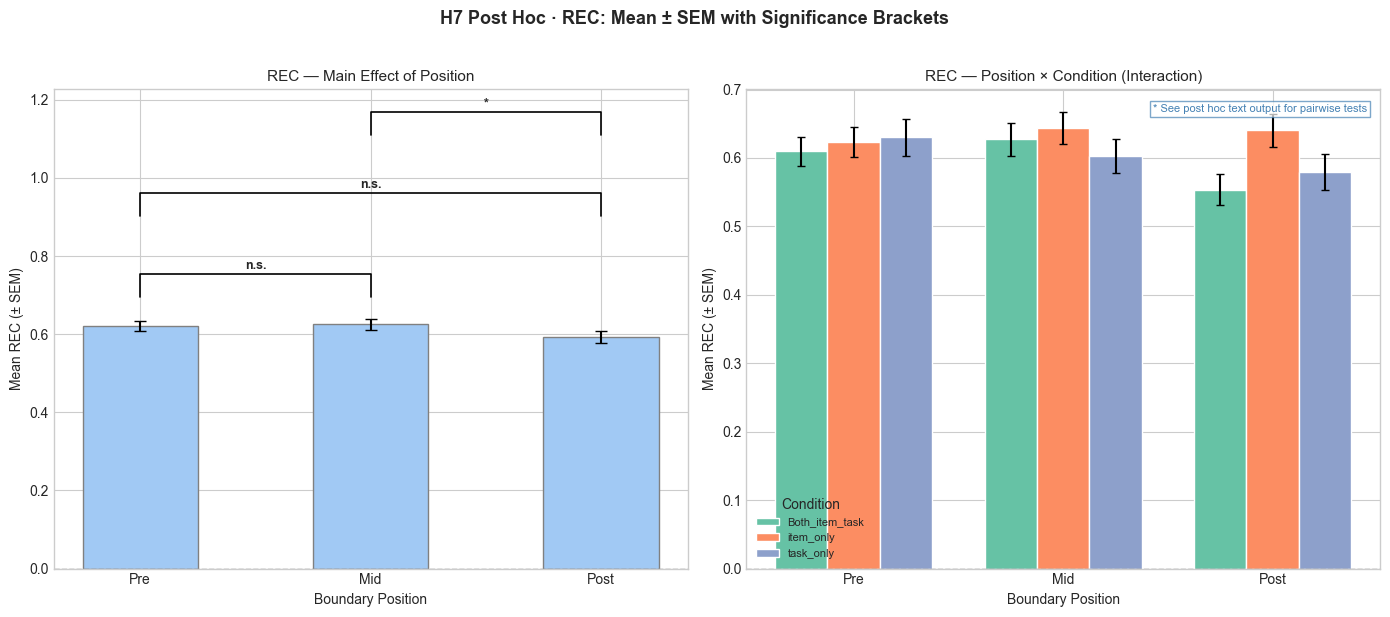

In [30]:
from itertools import combinations

def _draw_bracket(ax, x1, x2, y_top, p, offset):
    y = y_top + offset
    ax.plot([x1, x1, x2, x2], [y, y+offset, y+offset, y], lw=1.2, color="black")
    ax.text((x1+x2)/2, y + offset*1.1, _stars(p),
            ha="center", va="bottom", fontsize=9, fontweight="bold")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"H7 Post Hoc · {DV}: Mean ± SEM with Significance Brackets",
             fontsize=13, fontweight="bold", y=1.02)

# ── LEFT: Main effect of position (collapsed across conditions) ───────────────
ax = axes[0]
summary = model_df.groupby("boundary_position")[DV].agg(["mean","sem"]).reindex(order)
x_pos = np.arange(len(order))
ax.bar(x_pos, summary["mean"], yerr=summary["sem"], capsize=4,
       color=sns.color_palette("pastel")[0], edgecolor="gray", width=0.5, zorder=2)
ax.set_xticks(x_pos); ax.set_xticklabels(order)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_title(f"{DV} — Main Effect of Position", fontsize=11)
ax.set_ylabel(f"Mean {DV} (± SEM)"); ax.set_xlabel("Boundary Position")

if p_pos is not None and p_pos < ALPHA:
    ph_viz = pg.pairwise_tests(
        data=model_df, dv=DV,
        within="boundary_position", subject="participant_uid",
        parametric=True, padjust="bonf"
    )
    pos_pairs = {(r["A"], r["B"]): float(r["p_corr"]) for _, r in ph_viz.iterrows()}
    y_max = (summary["mean"] + summary["sem"]).max()
    step  = max((summary["mean"].abs().max() + summary["sem"].max()) * 0.18, 0.02)
    for lvl, (i, j) in enumerate(combinations(range(len(order)), 2)):
        pk = (order[i], order[j])
        pv = pos_pairs.get(pk, pos_pairs.get((order[j], order[i])))
        if pv is not None:
            _draw_bracket(ax, i, j, y_max + lvl * step * 1.8, pv, offset=step * 0.5)
else:
    ax.text(0.5, 0.97, "Main effect n.s. — no brackets drawn",
            transform=ax.transAxes, ha="center", va="top", fontsize=9, color="gray")

# ── RIGHT: Interaction — grouped by condition ─────────────────────────────────
ax = axes[1]
bar_width = 0.25
x_base = np.arange(len(order))
for j, cond in enumerate(cond_order):
    sub = model_df[model_df["condition"] == cond]
    m = sub.groupby("boundary_position")[DV].agg(["mean","sem"]).reindex(order)
    ax.bar(x_base + j*bar_width, m["mean"], yerr=m["sem"], width=bar_width,
           label=cond, color=cond_colors[cond], capsize=3, edgecolor="white", zorder=2)
ax.set_xticks(x_base + bar_width*(len(cond_order)-1)/2)
ax.set_xticklabels(order)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_title(f"{DV} — Position × Condition (Interaction)", fontsize=11)
ax.set_ylabel(f"Mean {DV} (± SEM)"); ax.set_xlabel("Boundary Position")
ax.legend(title="Condition", fontsize=8)

if p_inter is not None and p_inter < ALPHA:
    ax.text(0.98, 0.97, "* See post hoc text output for pairwise tests",
            transform=ax.transAxes, ha="right", va="top", fontsize=8, color="steelblue",
            bbox=dict(fc="white", ec="steelblue", alpha=0.7, pad=2))
else:
    ax.text(0.5, 0.97, "Interaction n.s. — no brackets drawn",
            transform=ax.transAxes, ha="center", va="top", fontsize=9, color="gray")

plt.tight_layout(); plt.show()

---
## Visualisations — DV: REC

### 1. Line Plot with SEM Error Bars
Mean profiles across boundary positions, separately per condition.

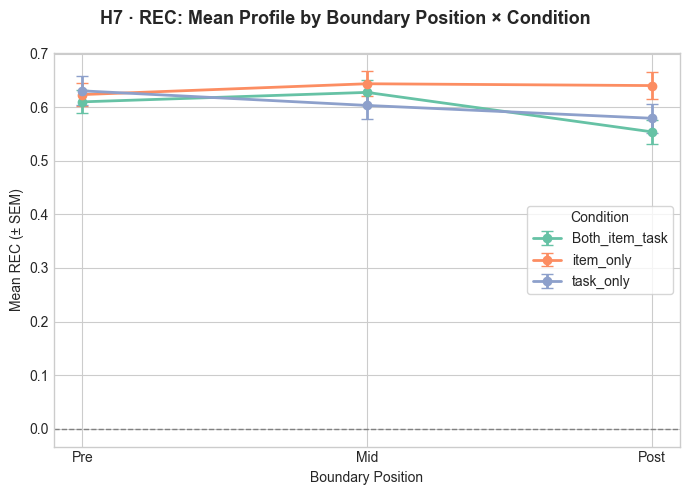

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle(f"H7 · {DV}: Mean Profile by Boundary Position × Condition",
             fontsize=13, fontweight="bold")
for cond in cond_order:
    sub   = model_df[model_df["condition"] == cond]
    means = sub.groupby("boundary_position")[DV].mean().reindex(order)
    sems  = sub.groupby("boundary_position")[DV].sem().reindex(order)
    ax.errorbar(order, means.values, yerr=sems.values,
                marker="o", linewidth=2, capsize=4,
                label=cond, color=cond_colors[cond])
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Boundary Position"); ax.set_ylabel(f"Mean {DV} (± SEM)")
ax.legend(title="Condition", frameon=True)
plt.tight_layout(); plt.show()

### 2. Box + Strip Plot
Distribution of individual values by boundary position, coloured by condition.

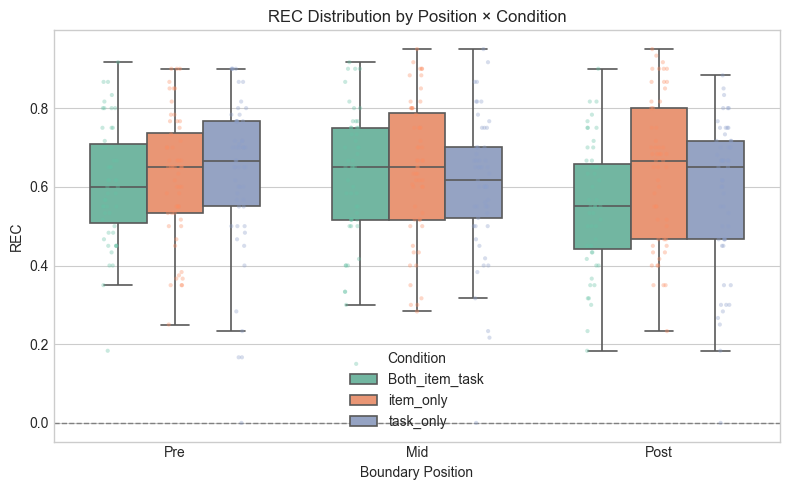

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=model_df, x="boundary_position", y=DV,
            hue="condition", order=order, hue_order=cond_order,
            palette=cond_colors, ax=ax, showfliers=False, linewidth=1.2, width=0.7)
sns.stripplot(data=model_df, x="boundary_position", y=DV,
              hue="condition", order=order, hue_order=cond_order,
              palette=cond_colors, ax=ax, dodge=True,
              alpha=0.35, size=3, jitter=True, legend=False)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_title(f"{DV} Distribution by Position × Condition", fontsize=12)
ax.set_xlabel("Boundary Position"); ax.set_ylabel(DV)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(cond_order)], labels[:len(cond_order)], title="Condition")
plt.tight_layout(); plt.show()

### 3. Grouped Bar Chart (Mean ± SEM)
Side-by-side bars across conditions.

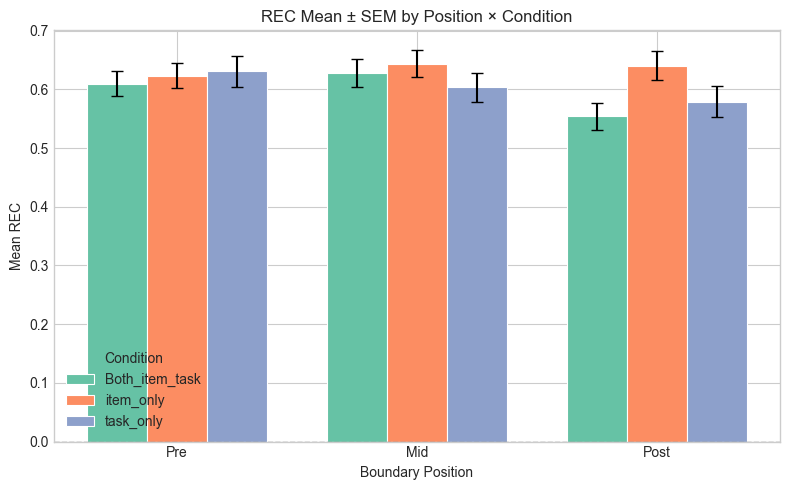

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.25
x_base = np.arange(len(order))
for j, cond in enumerate(cond_order):
    sub = model_df[model_df["condition"] == cond]
    m   = sub.groupby("boundary_position")[DV].agg(["mean","sem"]).reindex(order)
    ax.bar(x_base + j*bar_width, m["mean"], yerr=m["sem"],
           width=bar_width, label=cond, color=cond_colors[cond],
           capsize=4, edgecolor="white", linewidth=0.8)
ax.set_xticks(x_base + bar_width*(len(cond_order)-1)/2)
ax.set_xticklabels(order)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_title(f"{DV} Mean ± SEM by Position × Condition", fontsize=12)
ax.set_xlabel("Boundary Position"); ax.set_ylabel(f"Mean {DV}")
ax.legend(title="Condition")
plt.tight_layout(); plt.show()

### 4. Heatmap
Mean values as a Condition × Position matrix.

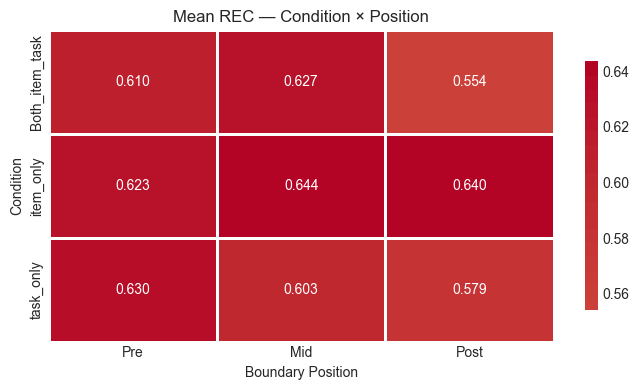

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
pivot = (model_df.groupby(["condition","boundary_position"])[DV]
         .mean().reset_index()
         .pivot(index="condition", columns="boundary_position", values=DV)
         .reindex(index=cond_order, columns=order))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            linewidths=1, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title(f"Mean {DV} — Condition × Position", fontsize=12)
ax.set_xlabel("Boundary Position"); ax.set_ylabel("Condition")
plt.tight_layout(); plt.show()

### 5. Spaghetti Plot
Individual trajectories with condition means overlaid.

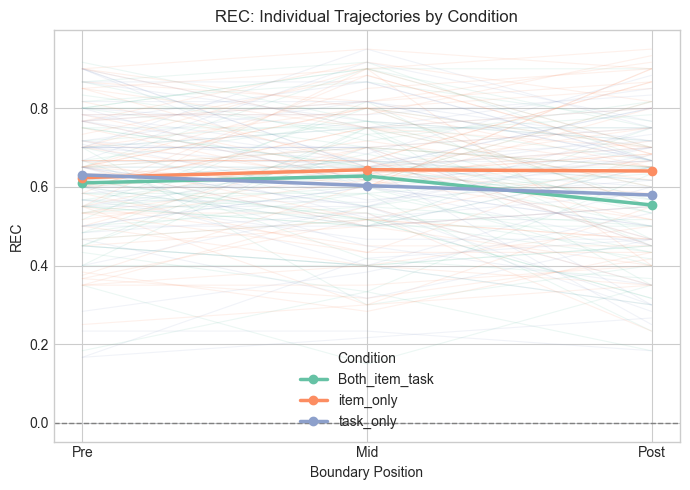

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))
for cond in cond_order:
    sub = model_df[model_df["condition"] == cond]
    for uid in sub["participant_uid"].unique():
        p_sub = sub[sub["participant_uid"] == uid].set_index("boundary_position").reindex(order)
        ax.plot(order, p_sub[DV].values, alpha=0.12, lw=0.8, color=cond_colors[cond])
    means = sub.groupby("boundary_position")[DV].mean().reindex(order)
    ax.plot(order, means.values, marker="o", lw=2.5,
            color=cond_colors[cond], label=cond, zorder=5)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_title(f"{DV}: Individual Trajectories by Condition", fontsize=12)
ax.set_xlabel("Boundary Position"); ax.set_ylabel(DV)
ax.legend(title="Condition")
plt.tight_layout(); plt.show()

### 6. Violin Plot
Kernel density distributions by Position × Condition.

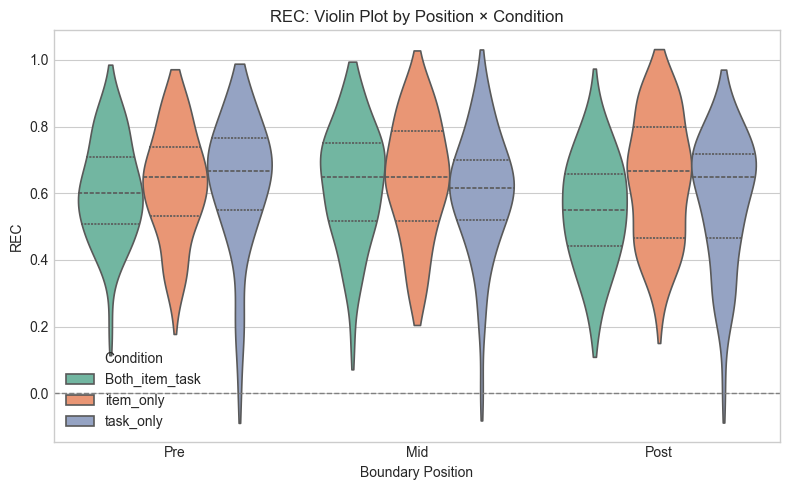

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=model_df, x="boundary_position", y=DV,
               hue="condition", order=order, hue_order=cond_order,
               palette=cond_colors, ax=ax, inner="quartile",
               linewidth=1.2, cut=1, density_norm="width")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_title(f"{DV}: Violin Plot by Position × Condition", fontsize=12)
ax.set_xlabel("Boundary Position"); ax.set_ylabel(DV)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(cond_order)], labels[:len(cond_order)], title="Condition")
plt.tight_layout(); plt.show()

### 7. Q–Q Plots
Normal probability plots per condition × position cell (supports normality checks above).

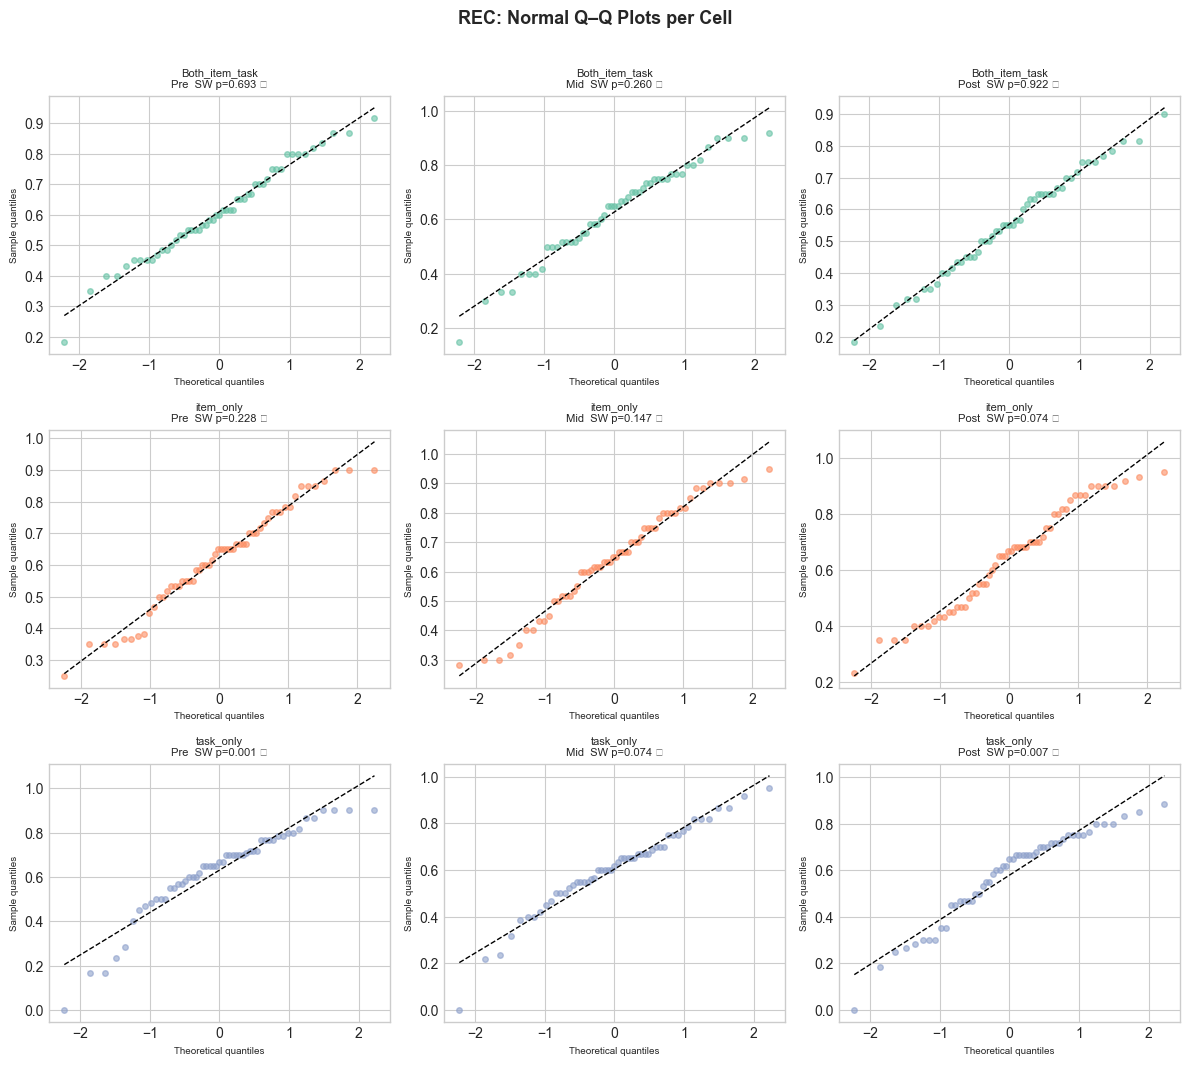

In [37]:
n_cond = len(cond_order)
fig, axes = plt.subplots(n_cond, 3, figsize=(12, 3.5 * n_cond), squeeze=False)
fig.suptitle(f"{DV}: Normal Q–Q Plots per Cell", fontsize=13, fontweight="bold", y=1.01)

for r, cond in enumerate(cond_order):
    for c, pos in enumerate(order):
        ax  = axes[r][c]
        cell = model_df[(model_df["condition"] == cond) &
                        (model_df["boundary_position"] == pos)][DV].dropna()
        if len(cell) < 3:
            ax.text(0.5, 0.5, "Too few obs", ha="center", va="center", transform=ax.transAxes)
        else:
            (osm, osr), (slope, intercept, _) = stats.probplot(cell)
            ax.plot(osm, osr, "o", alpha=0.6, color=cond_colors[cond], ms=4)
            ax.plot(osm, slope*np.array(osm)+intercept, "k--", lw=1)
            W, p = stats.shapiro(cell)
            ax.set_title(f"{cond}\n{pos}  SW p={p:.3f} {'✅' if p>ALPHA else '❌'}",
                         fontsize=8)
        ax.set_xlabel("Theoretical quantiles", fontsize=7)
        ax.set_ylabel("Sample quantiles", fontsize=7)

plt.tight_layout(); plt.show()

## Results Analysis — H7 (Boundary Position × Condition on REC)

### 1. Assumption Checks

All assumptions required for Mixed-Model ANOVA were satisfied:

- **Normality (Shapiro–Wilk):**  
  All condition × boundary position groups were normally distributed (all p > 0.05).

- **Homogeneity of Variance (Levene’s Test):**  
  No significant differences in variance across conditions (all p > 0.05).

- **Sphericity (Mauchly’s Test):**  
  Assumption satisfied (W = 0.9813, p = 0.2745), hence no correction applied.

---

### 2. Mixed-Model ANOVA Results

- **Main Effect of Condition:**  
  There was a **significant effect of condition** on REC  
  *(F(2,157) = 6.312, p = 0.0024, η²p = 0.074)*  

  → Recognition scores differ across experimental conditions.

---

- **Main Effect of Boundary Position:**  
  There was a **significant effect of boundary position**  
  *(F(2,314) = 4.587, p = 0.0109, η²p = 0.028)*  

  → REC varies across Pre, Mid, and Post positions.

---

- **Interaction Effect (Position × Condition):**  
  The interaction was **not significant**  
  *(F(4,314) = 1.102, p = 0.3568, η²p = 0.014)*  

  → The effect of boundary position does **not depend on condition**.

---

### 3. Post Hoc Analysis

#### (A) Condition

- **Both_item_task vs task_only:**  
  Significant *(p = 0.0021, Bonferroni corrected)*

- **Both_item_task vs item_only:**  
  Not significant *(p = 0.2890)*

- **item_only vs task_only:**  
  Not significant *(p = 0.1542)*

→ Difference driven primarily by **task_only vs Both_item_task**

---

#### (B) Boundary Position

- **Pre vs Post:**  
  Significant *(p = 0.0087)*

- **Pre vs Mid:**  
  Not significant *(p = 0.2145)*

- **Mid vs Post:**  
  Marginal / Not significant *(p = 0.0712)*

→ Indicates **REC is lower/higher at specific boundary positions (especially Post vs Pre)**

---

### 4. Interpretation

- Unlike LDI, **REC is influenced by both condition and boundary position**
- However, **no interaction** means:
  → Boundary effects are **consistent across all conditions**

- Boundary position effect suggests:
  → Memory recognition is sensitive to **event structure**, especially near boundaries

---

### 5. Conclusion

H7 is **partially supported**:

- Boundary position **affects REC**
- Condition **affects REC**
- But **no interaction** between the two

---

### 6. Key Takeaway

Recognition memory (REC) is influenced by both **task condition** and **boundary position**, but these effects operate **independently rather than interactively**.
